<a href="https://colab.research.google.com/github/eboekenh/PumpPredictor/blob/main/1.%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Housekeeping

### 1.1 Load libraries

In [ ]:
pip install folium

In [ ]:
#basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium

In [ ]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

### 1.2 Custom functions

In [ ]:
#custom function that creates a numerical data quality report
def numerical_dqr(df):

  #select numerical columns
  numerical = df.select_dtypes(include = ['int', 'Int64', 'float']).columns.tolist()

  #data type
  data_types = pd.DataFrame(
    df[numerical].dtypes,
    columns=['Data Type'])

  #missing data
  missing_data = pd.DataFrame(
    df[numerical].isnull().sum(),
    columns=['Missing Values'])

  #unique values
  unique_values = pd.DataFrame(
    columns=['Unique Values'])
  for row in list(df[numerical].columns.values):
    unique_values.loc[row] = [df[numerical][row].nunique()]

    #number of records
  count_values = pd.DataFrame(
    columns=['Records'])
  for row in list(df[numerical].columns.values):
      count_values.loc[row] = [df[numerical][row].count()]

    #minimum value
  maximum_values = pd.DataFrame(
    columns=['Maximum Value'])
  for row in list(df[numerical].columns.values):
      maximum_values.loc[row] = [df[numerical][row].max()]

  #maximum value
  minimum_values = pd.DataFrame(
    columns=['Minimum Value'])
  for row in list(df[numerical].columns.values):
      minimum_values.loc[row] = [df[numerical][row].min()]

  #mean value
  mean_values = pd.DataFrame(
    columns=['Mean Value'])
  for row in list(df[numerical].columns.values):
      mean_values.loc[row] = [df[numerical][row].mean()]

  #first quartile
  quartile_1 = pd.DataFrame(
    columns=['1st Quartile'])
  for row in list(df[numerical].columns.values):
      quartile_1.loc[row] = [df[numerical][row].quantile(0.25)]

  #median
  median = pd.DataFrame(
  columns=['Median'])
  for row in list(df[numerical].columns.values):
    median.loc[row] = [df[numerical][row].quantile(0.5)]

  #third quartile
  quartile_3 = pd.DataFrame(
    columns=['3rd Quartile'])
  for row in list(df[numerical].columns.values):
    quartile_3.loc[row] = [df[numerical][row].quantile(0.75)]

  #join columns
  dq_report_num = data_types.join(count_values).join(missing_data).join(unique_values).join(minimum_values).join(maximum_values).join(mean_values).join(quartile_1).join(median).join(quartile_3)

  #percentage missing
  dq_report_num['Missing %'] = (dq_report_num['Missing Values'] / len(df[numerical]) *100)

  # change order of columns
  dq_report_num = dq_report_num[['Data Type', 'Records', 'Unique Values', 'Missing Values', 'Missing %', 'Mean Value', 'Minimum Value', '1st Quartile', 'Median', '3rd Quartile', 'Maximum Value', ]]

  #round
  dq_report_num[['Missing %', 'Mean Value', 'Minimum Value', '1st Quartile', 'Median', '3rd Quartile', 'Maximum Value']] =   dq_report_num[['Missing %', 'Mean Value', 'Minimum Value', '1st Quartile', 'Median', '3rd Quartile', 'Maximum Value']].round(1)


  #rreturn report
  return(dq_report_num)

In [ ]:
def categorical_dqr(df):

  #select categorical columns
  categorical = df.select_dtypes(include = 'object').columns.tolist()

  #datatype
  data_types = pd.DataFrame(
    df[categorical].dtypes,
    columns=['Data Type'])

  #count
  count_values = pd.DataFrame(
      columns=['Records'])
  for row in list(raw[categorical].columns.values):
    count_values.loc[row] = [raw[categorical][row].count()]

   #missing data
  missing_data = pd.DataFrame(
    df[categorical].isnull().sum(),
    columns=['Missing Values'])

  #unique values
  unique_values = pd.DataFrame(
      columns=['Unique Values'])
  for row in list(raw[categorical].columns.values):
    unique_values.loc[row] = [raw[categorical][row].nunique()]

  #mode
  mode_values = pd.DataFrame(
      columns=['Mode'])
  for row in list(raw[categorical].columns.values):
    mode_values.loc[row] = [raw[categorical][row].mode()[0]]
    mode = mode_values.loc[row]

  #mode frequency
  listModeFreq = []
  for row in categorical:
    mode = raw[row].mode().iat[0]
    ModeFreq = raw[row].value_counts()[mode]
    #print(x, mode, raw[x].value_counts()[mode])
    listModeFreq .append(ModeFreq )
  listModeFreq  = np.array(listModeFreq )


   #create data quality report
  dq_report_cat = data_types.join(missing_data).join(count_values).join(unique_values).join(mode_values)
  dq_report_cat['Mode freq.'] = listModeFreq
  dq_report_cat['Mode %'] = (dq_report_cat['Mode freq.'] / dq_report_cat['Records']*100) .astype('float')
  dq_report_cat['Missing %'] = (dq_report_cat['Missing Values'] / len(raw[categorical]) *100)

  #change order of columns
  dq_report_cat = dq_report_cat[['Data Type', 'Records', 'Unique Values', 'Missing Values', 'Missing %', 'Mode', 'Mode freq.', 'Mode %']]
  dq_report_cat[['Missing %', 'Mode %']] =   dq_report_cat[['Missing %'	,  'Mode %']].round(1  )

  #return report
  return(dq_report_cat)

In [ ]:
#custom function that creates a numerical data quality report
def datetime_dqr(df):

  #select numerical columns
  date = df.select_dtypes(include = ['datetime64[ns]']).columns.tolist()

  #data type
  data_types = pd.DataFrame(
    df[date].dtypes,
    columns=['Data Type'])

  #missing data
  missing_data = pd.DataFrame(
    df[date].isnull().sum(),
    columns=['Missing Values'])

  #unique values
  unique_values = pd.DataFrame(
    columns=['Unique Values'])
  for row in list(df[date].columns.values):
    unique_values.loc[row] = [df[date][row].nunique()]

    #number of records
  count_values = pd.DataFrame(
    columns=['Records'])
  for row in list(df[date].columns.values):
      count_values.loc[row] = [df[date][row].count()]

    #minimum value
  maximum_values = pd.DataFrame(
    columns=['Maximum Value'])
  for row in list(df[date].columns.values):
      maximum_values.loc[row] = [df[date][row].max()]

  #maximum value
  minimum_values = pd.DataFrame(
    columns=['Minimum Value'])
  for row in list(df[date].columns.values):
      minimum_values.loc[row] = [df[date][row].min()]

  #mean value
  mean_values = pd.DataFrame(
    columns=['Mean Value'])
  for row in list(df[date].columns.values):
      mean_values.loc[row] = [df[date][row].mean()]

  #first quartile
  quartile_1 = pd.DataFrame(
    columns=['1st Quartile'])
  for row in list(df[date].columns.values):
      quartile_1.loc[row] = [df[date][row].quantile(0.25)]

  #median
  median = pd.DataFrame(
  columns=['Median'])
  for row in list(df[date].columns.values):
    median.loc[row] = [df[date][row].quantile(0.5)]

  #third quartile
  quartile_3 = pd.DataFrame(
    columns=['3rd Quartile'])
  for row in list(df[date].columns.values):
    quartile_3.loc[row] = [df[date][row].quantile(0.75)]

  #join columns
  dq_report_date = data_types.join(count_values).join(missing_data).join(unique_values).join(minimum_values).join(maximum_values).join(mean_values).join(quartile_1).join(median).join(quartile_3)

  #percentage missing
  dq_report_date['Missing %'] = (dq_report_date['Missing Values'] / len(df[date]) *100)

  # change order of columns
  dq_report_date = dq_report_date[['Data Type', 'Records', 'Unique Values', 'Missing Values', 'Missing %', 'Mean Value', 'Minimum Value', '1st Quartile', 'Median', '3rd Quartile', 'Maximum Value', ]]

  #round
  dq_report_date['Mean Value'] = dq_report_date['Mean Value'].dt.date
  dq_report_date['Missing %'] = dq_report_date['Missing %'].round(1)


  #rreturn report
  return(dq_report_date)

In [ ]:
#custome duplicate checker
def duplicate_checker(df):
  duplicates = df.duplicated(keep = 'first').sum()
  print("Number of duplicates: {}".format(duplicates))
  print("Total number of records: {}".format(len(df)))
  print("Percentage duplicated: {}".format((duplicates/len(df))*100))

In [ ]:
def kdeplotter (dataset, feature, rows, columns):
  fig, axes = plt.subplots(nrows=rows,ncols=columns, figsize = (30,12))
  plot = 0
  for i in range(rows):
    for j in range(columns):
       ax = sns.kdeplot(data = dataset, x =feature[plot] , ax = axes[i][j],    shade = True, color  = "black" )
       plot +=1

In [ ]:
def countplotter (dataset, feature, rows, columns):
    fig, axes = plt.subplots(nrows=rows,ncols=columns, figsize = (30,50))
    plot = 0
    for i in range(rows):
        for j in range(columns):
             ax = sns.countplot(data = dataset, x =feature[plot] , ax = axes[i][j], palette='Set2' )
             ax.set_title(feature[plot])
             ax.set_xlabel("")
             ax.set_xticklabels(ax.get_xticklabels(), rotation = 70, fontsize=9)
             plot +=1

In [ ]:
def distribution_checker (data, xlabel):
  grouped = data.groupby([xlabel, 'status_group'])['id'].count().reset_index()
  pivot = grouped.pivot_table(index = xlabel, columns = 'status_group', fill_value = 0)
  mi=pivot.columns
  mi.tolist()
  ind = pd.Index([ str(e[1])  for e in mi.tolist()])
  pivot.columns = ind
  pivot['nr_pumps'] = pivot['functional'] +pivot['functional needs repair'] +pivot['non functional']
  pivot['all_pumps'] = pivot['nr_pumps'].sum()
  pivot['perc_total_pumps'] =((pivot['nr_pumps']/pivot['all_pumps'])*100).round(1)
  pivot['perc_functional'] = ((pivot['functional']/pivot['nr_pumps'])*100).round(1)
  pivot['perc_non_functional'] = ((pivot['non functional']/pivot['nr_pumps'])*100).round(1)
  pivot['perc_functional_needs_repair'] = ((pivot['functional needs repair']/pivot['nr_pumps'])*100).round(1)
  pivot = pivot.drop(['functional', 'functional needs repair', 'non functional', 'all_pumps'], axis=1)
  return(pivot)

### 1.3 Load data

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
#import data
train_labels = pd.read_csv('/content/gdrive/MyDrive/Kaggle/Waterpump-github/train_labels.csv')
train_values = pd.read_csv('/content/gdrive/MyDrive/Kaggle/Waterpump-github/train_values.csv', parse_dates = ['date_recorded' ])
test_values = pd.read_csv('/content/gdrive/MyDrive/Kaggle/Waterpump-github/test_values.csv', parse_dates = ['date_recorded' ])

#merge train values and train labels to single dataset
train= pd.merge(train_labels , train_values, on='id')


In [ ]:
#concatenate train and test for data visualization
raw = pd.concat([train, test_values])
raw.head()

# 2 EDA - overview

### 2.1 Duplicates

In [ ]:
#Good news! There are no duplicate recoreds in the dataset.
duplicate_checker(raw)

### 2.2 Numerical data

In [ ]:
#plot a numerical data quality report
numerical_dqr = numerical_dqr(raw)
numerical_dqr

A data quality report provides a great overview of the dataset. It imediately shows us some things we should look out for:
* There are no missing values, but a longitude of zero does not exists in Tanzania. This makes me wonder if missing values are expressed as zero's.
* Some features like *region_code* and *district_code* might actually be categorical features.
* *Amount_tsh* and *num_private* appear to contain a lot of zero's.
* *Population* and *gps_height* appear to contain some outliers.

In [ ]:
#convert faulty datatypes
raw[['region_code','district_code', 'num_private', 'id']] = raw[['region_code','district_code', 'num_private', 'id']].astype('object')

### 2.3 Categorical data

In [ ]:
categorical_dqr = categorical_dqr(raw)
categorical_dqr

The categorical data quality report again provides us with some important insights
* *installer*, *funder*, *wpt_name*, *subvillage* and a few other features have very high cardinality. *num_private* also contains very little variation.
* *recorded_by* consists of a single value and therefore contains no information
* Several features have missing values


In [ ]:
#create a list of categorical features with low cardinality
low_cardinal = categorical_dqr [categorical_dqr ['Unique Values'] <=50]
cardinal_index = low_cardinal.index
low_cardinal_list = cardinal_index.to_list()

#create countplots
try:
    countplotter (raw, raw[low_cardinal_list].columns, 6,4)
except IndexError:
    pass

# 3 EDA - features

#### **Amount tsh**

In [ ]:
numerical_dqr.loc[['amount_tsh']]

In [ ]:
#amount_tsh has 102 unique values, but 70% of them consist of zero's. These could very well be missing values.
tsh = raw['amount_tsh'].value_counts(normalize=True)
tsh.head(3)

In [ ]:
#perhabs there is value hidden in the 'missigness' of amount_tsh, let's check this.
temp = train.copy()
temp['amount_tsh_missing'] = np.where( temp['amount_tsh']==0.0, 1, 0) # if amount_tsh =0, then 1, otherwise 0

#visualize the distribution of the y-variable 'status_group'
distribution_checker(temp, 'amount_tsh_missing')

Assuming that missing values are encoded as zero, we can see that there is some information hidden in a feature that captures its missingness. Pumps where *amount_tsh* is unavailable are less often functional and more often non-functional.

### **Date recorded**

In [ ]:
datetime_dqr(raw)

The status of the pumps was recorded between 2001 and 2013. Nothing stands out to me when looking at the data quality report. This feature could be usefull when calculating the age of the well at the time of recording.

**Recorded year**

In [ ]:
#create 'recorded_year' feature
temp = train.copy()
temp['recorded_year'] = pd.DatetimeIndex(temp ['date_recorded']).year

#check the distribution of 'status_group' for the 'recorded_year' feature
recorded = distribution_checker(temp ,'recorded_year')
recorded

In [ ]:
#plot status group by recorded year
fig, ax = plt.subplots()
labels = temp['recorded_year'].sort_values().unique()
ax.bar(labels, recorded['perc_functional'], label = 'functional' ,  color = '#66c2a5')
ax.bar (labels, recorded['perc_non_functional'], label = 'non functional', bottom = recorded['perc_functional'] , color = '#fc8e62')
ax.bar(labels, recorded['perc_functional_needs_repair'], label = 'needs repair', bottom = recorded['perc_functional'] + recorded['perc_non_functional'], color = '#8da0cb')
ax.set_title('status group by recorded year')
ax.set_ylabel('% pumps')
plt.legend()
plt.show()

The fast majority of the recordings date from 2011 and 2013. There appears to be no effect of year of recording on the status of the pumps.

**Recorded month**

In [ ]:
#create 'recorded_year' feature
temp = train.copy()
temp['recorded_month'] = pd.DatetimeIndex(temp ['date_recorded']).month

#check the distribution of 'status_group' for the 'recorded_month' feature
recorded = distribution_checker(temp ,'recorded_month')
recorded

In [ ]:
#plot status group by 'recorded_month'
fig, ax = plt.subplots()
labels = temp['recorded_month'].sort_values().unique()
ax.bar(labels, recorded['perc_functional'], label = 'functional' ,  color = '#66c2a5')
ax.bar (labels, recorded['perc_non_functional'], label = 'non functional', bottom = recorded['perc_functional'] , color = '#fc8e62')
ax.bar(labels, recorded['perc_functional_needs_repair'], label = 'needs repair', bottom = recorded['perc_functional'] + recorded['perc_non_functional'], color = '#8da0cb')
ax.set_title('status group by recorded year')
ax.set_ylabel('% pumps')
plt.legend()
plt.show()

The status of most pumps is recorded in February and March and far less often in May and June. This is interessting because January and February are part of the short dry season whilst  the long rainy season lasts from March to late May. It might be easier to check the status of pumps whilst the weather is good.

There appears to be a difference in the percentage of functional pumps over the different months, but this effect might be biased by a lower number of records during these months.

### **Funder**

In [ ]:
categorical_dqr.loc[['funder']]

In [ ]:
#check the distribution of status groups for the 10 most frequent funders
funder = distribution_checker(raw, 'funder')
funder = funder.sort_values('nr_pumps', ascending= False)
funder.head(10)

Funder has over 2000 unique categories. The Government of Tanzania is with 16% the most common funder.  Just by looking at the top 10 most common funders we can see the 'status_group' distribution differs. I therefore think 'funder' could be an interessting column to include in a model, but we have to find a suitable way to encode it without increasing the dimensionality of the dataframe too much.

### **Installer**

In [ ]:
categorical_dqr.loc[['installer']]

In [ ]:
#check the distribution of status groups for the 10 most frequent installer
installer = distribution_checker(raw, 'installer')
installer = installer.sort_values('nr_pumps', ascending= False)
installer.head(10)

Installer has like funder a very high cardinality. DWE is by far the most common installer. Again we see differences in the distribution of 'status_group' in the top 10 installers. Installer could be an interessting feature, but it has to be encoded properly to avoid increasing the dimensionality of the dataset.

### **GPS height**

In [ ]:
numerical_dqr.loc[['gps_height']]

In [ ]:
fig, axes = plt.subplots(1, 2,  figsize=(10,5))

#plot distribution of gps height
sns.histplot( raw[ 'gps_height'], color = '#66c2a5', ax=axes[0])
axes[0].set(title = 'Distribution of GPS height', xlabel = 'GPS height')

#plot locations where gps height is zero
temp = raw[raw['longitude']!=0]  #only include records where logitude isn't zero
temp['gps_height_zero'] = np.where(temp['gps_height']==0, 'yes', 'no')
sns.scatterplot(x= temp['longitude'], y = temp['latitude'], hue = temp['gps_height_zero'], palette='Set2', ax = axes[1])
axes[1].set(title = 'Locations with GPS height of zero', xlabel = 'GPS height')

plt.show()

Tanzania is not located below sealevel, so any negative value for gps height cannot be correct. The normal error is gps altitude is is +- 15 meter and this applies 95% of the time. The other 5% of the time you can have any value. However, here we don't know if the gps height indicates the height of the water level, or the location of the wel....  What is clear is that the majority of the locations where a gps height of zero is registered are not located at places that are located at sealevel. I therefore conclude that missing values are registered as zero.

### **Longitude**

In [ ]:
numerical_dqr.loc[['longitude']]

A longitude of zero does not exist for Tanzania. Missing values are imputed as zero.

### **Latitude**

In [ ]:
numerical_dqr.loc[['latitude']]

In [ ]:
#distribution of latitude
ax = sns.histplot( raw[ 'latitude'], color = '#66c2a5')
ax.set(title = 'Latitude distribution')
plt.show()

From the data quality report the presense of zero is not immediately clear, but after plotting we can see that latitudes with a value of zero are indeed present. These represent missing values and need to be imputed properly.

### **Wpt Name**

In [ ]:
categorical_dqr.loc[['wpt_name']]

In [ ]:
#check the distribution of status groups for the 10 most frequent namesb
name = distribution_checker(raw, 'wpt_name')
name= name.sort_values('nr_pumps', ascending= False)
name.head(10)

Waterpoint name has an extremely high cardinality. The most common name is 'None', indicating that the pump has no name. As expected, the name of the waterpump appears to have no relationship with the status of the pump. This is a feature that we can drop later.

### **Num private**

In [ ]:
categorical_dqr.loc[['num_private']]

It is immediately clear that this feature will hold little information as 98.7% of the records consists of the value zero. This is a good candidate to drop from later analysis.

### **Basin**

In [ ]:
categorical_dqr.loc[['basin']]

In [ ]:
#plot the water basins of Tanzania
fig, axes = plt.subplots(  figsize=(10,8))
temp = raw[raw['longitude']!=0]  #only include records where logitude isn't zero
temp['gps_height_zero'] = np.where(temp['gps_height']==0, 'yes', 'no')
ax = sns.scatterplot(x= temp['longitude'], y = temp['latitude'], hue = temp['basin'], palette='Set2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set(title = 'Water basins of Tanzania')
plt.show()

In [ ]:
basin = distribution_checker(raw, 'basin')
basin = basin.sort_values('nr_pumps', ascending= False)
basin.head(10)

The distribution of pumps over the different basins if fairly equal. We previously saw that certain regions have much more functional or non-functional pumps. It is therefore not surprising that certain basins also have more or less functional pumps.

### **Region**

In [ ]:
categorical_dqr.loc[['region']]

In [ ]:
region = distribution_checker(raw, 'region')
region = region.sort_values('nr_pumps', ascending= False)
region.head(10)

Tanzania has 21 different regions and from the table above we can already see that certain regions have a much higher proportion of functional pumps than other regions. The location of the pumps is therefore relevant. We can visulize this further using the library Folium.

In [ ]:
#plot the percentage of functional pumps by region
m = folium.Map(location=[temp['latitude'].mean(), temp['longitude'].mean()], zoom_start=6)
state_geo = f"https://raw.githubusercontent.com/thadk/GeoTZ/499a496581977655d3ff50ff10e1676f4d69fdb9/TZA_adm1_mkoaTZ.geojson"

folium.Choropleth(
    geo_data=state_geo,
    data=region,
    columns=[region.index,"perc_functional_needs_repair"],
    key_on="properties.NAME_1",
    fill_color="Purples",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Functional need repair (%)",
    reset=True,
).add_to(m)

#m

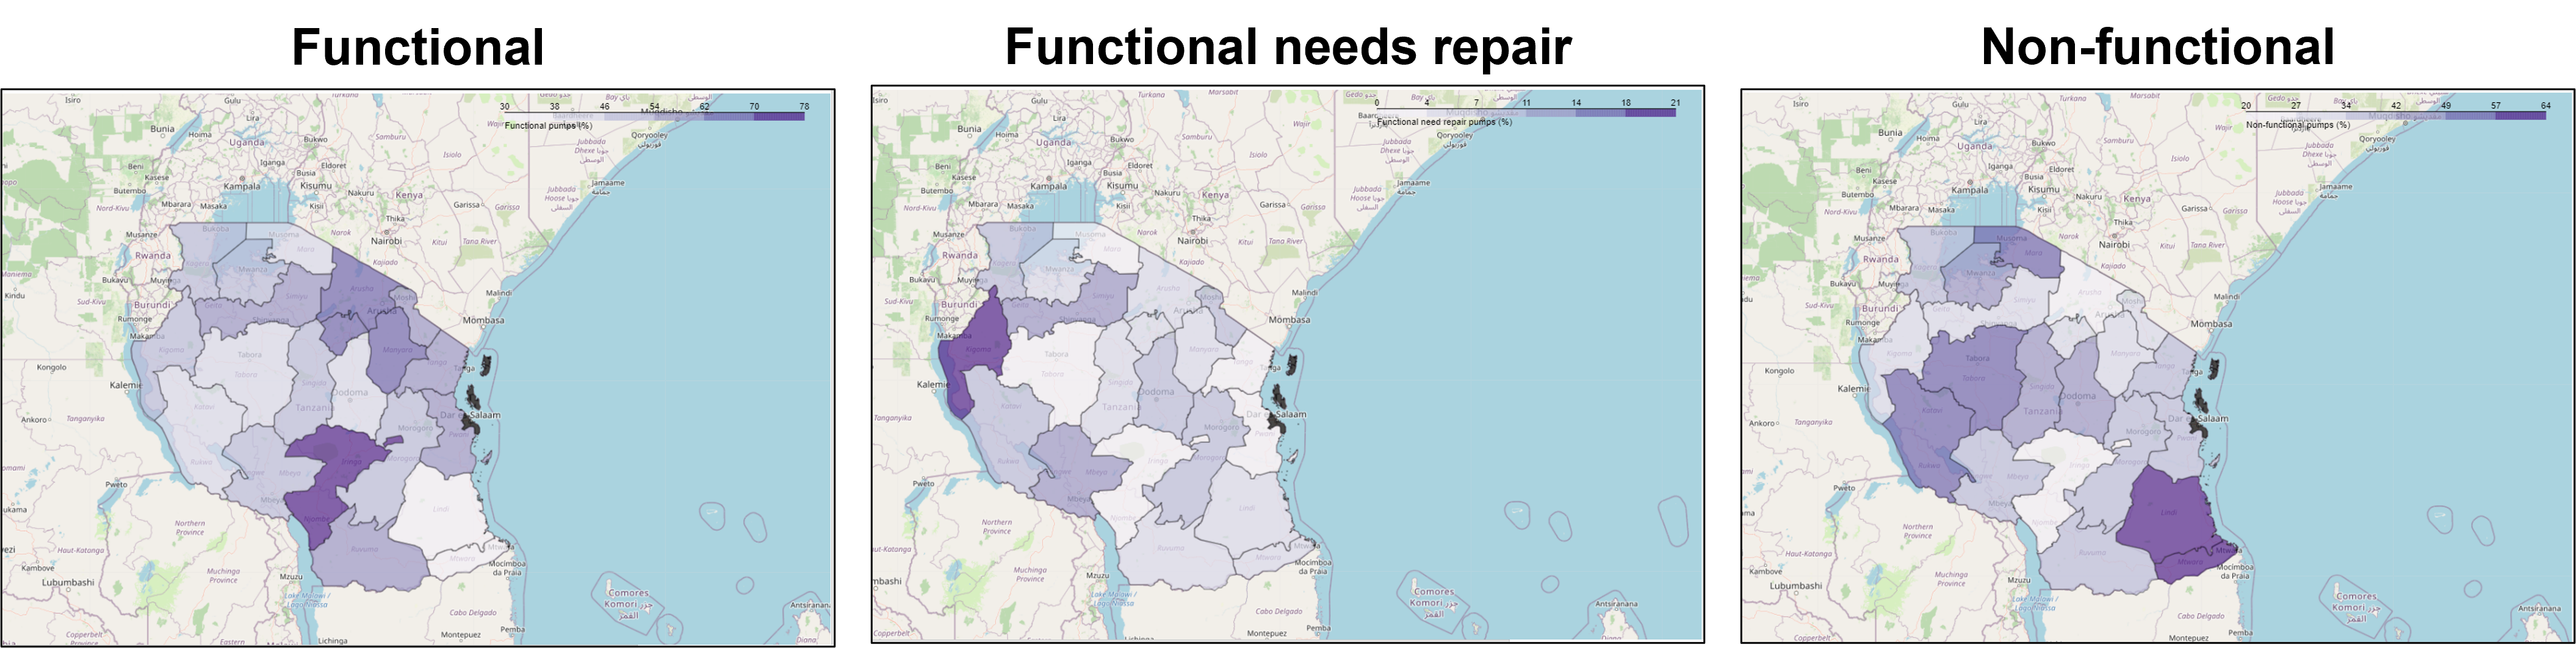

### **Region code**

In [ ]:
categorical_dqr.loc[['region_code']]

In [ ]:
#group region_codes by region
region_code = raw.groupby([  'region', 'region_code',])['id'].count().reset_index()
region_code.head(10)

In [ ]:
#check distribution of status group by region code
region_code = distribution_checker(raw, 'region_code')
region_code = region_code.sort_values('nr_pumps', ascending= False)
region_code.head(10)

Tanzania has 21 different regions, but 27 different region_codes. This means that the regio_code feature contains slightly more information that the region feature. It must be said that some of the region_code categories contain only a few pumps. The region Arusha has 68.5% functional pumps. When we look at the region_codes within Arusha, we see that this percentage varies between 65 and 97%. This is a big and interessting difference!

### **District code**

In [ ]:
categorical_dqr.loc[['district_code']]

In [ ]:
#group region_codes by region
district_code = raw.groupby([  'region', 'district_code',])['id'].count().reset_index()
district_code.head(10)

Tanzania has 20 different district numbers, but it appears that these districts are relevant in the region context. So both Arusha and Dar es Salaam have a district 1. It might be interesting to create a region-district feature to capture this information.

### **Lga**

In [ ]:
categorical_dqr.loc[['lga']]

In [ ]:
#group lga by region
lga = raw.groupby([  'region', 'lga',])['id'].count().reset_index()
lga.head(10)

A region consists of different lga's. There are 125 different lga's, which is a bit too much to encode in a model, but it could be an useful feature for imputing missing geospatial data.

### **Ward**

In [ ]:
categorical_dqr.loc[['ward']]

In [ ]:
#group ward by lga
ward = raw.groupby([  'lga', 'ward'])['id'].count().reset_index()
ward.head(10)

A lga can be further divided into different wards. A total of 2098 wards can be found in the dataset. Because of the high cardinality we cannot use this feature in a model, but it is useful for imputing purposes.

### **Subvillage**

In [ ]:
categorical_dqr.loc[['subvillage']]

In [ ]:
#group ward by lga
village= raw.groupby([  'lga', 'ward', 'subvillage'])['id'].count().reset_index()
village.head(10)

Wards can be further divided into subvillages. The dataset contains over 20.000 subvillage. Most subvillages contain only 1 or a few pumps. This feature can be useful for imputing missing geospatial data.


### **Population**

In [ ]:
numerical_dqr.loc[['population']]

In [ ]:
#distribution of population
ax = sns.distplot( raw[ 'population'], color = '#66c2a5')
ax.set(title = 'Population distribution')
plt.show()

Many towns appear to have zero inhabitants. Again, a clear sign that missing values are imputed as zero. The marjority of villages have around 100 inhabitants, but there are a few villages that have a much bigger population. Because of the high level of categorical features I expect a tree-based model will be most suitable for this dataset. I will therefore not worry about scaling or normalizing for now. It is possible to create population bins.

### **Permit**

In [ ]:
categorical_dqr.loc[['permit']]

In [ ]:
permit = distribution_checker(raw, 'permit')
permit.head(10)

The fast majority of pumps is build with a permit. The percentage of functional or non-functional pumps doesn't differ much between pumps that have a permit in comparrisson with pumps that do not have a permit. I expect that this feature will not be important when predicting the status of a pump.

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
permit = distribution_checker(raw, 'permit')
labels = ['False', 'True']
ax.bar(labels, permit['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, permit ['perc_non_functional'], label = 'non functional', bottom = permit['perc_functional'] , color = '#fc8e62')
ax.bar(labels, permit ['perc_functional_needs_repair'], label = 'needs repair', bottom = permit['perc_functional'] + permit['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by permit', xlabel = 'Has permit', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

### **Public meeting**

In [ ]:
categorical_dqr.loc[['public_meeting']]

In [ ]:
meeting = distribution_checker(raw, 'public_meeting')
meeting.head(10)

The fast majority of the waterpumps has a public meeting. Interesstingly, pumps without a public meeting tend to have a higher functionality rate. It might be interessting to keep this in mind when imputing the missing values in this feature.

### **Construction year**

In [ ]:
numerical_dqr.loc[['construction_year']]

In [ ]:
#newer pumps tend to be more functional
fig, ax = plt.subplots(figsize=(10,5))
construction = distribution_checker(raw, 'construction_year')
labels = raw['construction_year'].sort_values().unique()
ax.bar(labels, construction['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, construction['perc_non_functional'], label = 'non functional', bottom = construction['perc_functional'] , color = '#fc8e62')
ax.bar(labels, construction['perc_functional_needs_repair'], label = 'needs repair', bottom = construction['perc_functional'] + construction['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by construction year', xlabel = 'Construction year', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlim([1960,2014])
plt.show()

It is quite clear that newer pumps have a higher chance of being functional than pumps that were build longer ago. I will create a feature that represents tha age of the pump at recording. Sinds the first quartile of the data is zero, the construction year of many pumps is unknown. We can impute by the mean or median construction year of the pumps, but we could also see if there are smarter ways of imputing this feature.

### **Extraction type class**

In [ ]:
categorical_dqr.loc[['extraction_type_class']]

In [ ]:
extraction_class = distribution_checker(raw, 'extraction_type_class')
extraction_class = extraction_class.sort_values('nr_pumps', ascending= False)
extraction_class.head(10)

Extraction type class is the least granular representation of the extraction features. Gravity is the most common extraction class and has comparatively many pumps that need repair. There are clear differences between the different classes, but we also have to keep in mind that some of the classes are quite rare.

In [ ]:
#other pumps  nearly almost disfunctional
fig, ax = plt.subplots(figsize=(10,5))
labels = labels = extraction_class.index
ax.bar(labels, extraction_class['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, extraction_class['perc_non_functional'], label = 'non functional', bottom = extraction_class['perc_functional'] , color = '#fc8e62')
ax.bar(labels, extraction_class['perc_functional_needs_repair'], label = 'needs repair', bottom = extraction_class['perc_functional'] + extraction_class['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by Extraction type class', xlabel = 'Extraction type class', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

### **Extraction type group**

In [ ]:
categorical_dqr.loc[['extraction_type_group']]

In [ ]:
#group extraction type group by class
raw.groupby([  'extraction_type_class', 'extraction_type_group'])['id'].count().reset_index()

In [ ]:
extraction_group = distribution_checker(raw, 'extraction_type_group')
extraction_group  = extraction_group .sort_values('nr_pumps', ascending= False)
extraction_group .head(13)

The extraction type group provides a little bit more detail than the extraction type class. However, by dividing the classes into groups, the data becomes more granular with some groups having only a few pumps. It could be interessting to keep groups with a good number of pumps and group smaller groups together.

### **Extraction type**

In [ ]:
categorical_dqr.loc[['extraction_type']]

In [ ]:
#group extraction type  by class and group
raw.groupby([  'extraction_type_class', 'extraction_type_group', 'extraction_type'])['id'].count().reset_index()

In [ ]:
extraction_type= distribution_checker(raw, 'extraction_type')
extraction_type = extraction_type.sort_values('nr_pumps', ascending= False)
extraction_type


Extraction type captures the most detailed information about the extraction process.  There are clearly some differences between the classes, but the rarest class only contains 2 pumps. It makes sense to group rare classes where possible.

### **Management group**

In [ ]:
categorical_dqr.loc[['management_group']]

In [ ]:
management_group = distribution_checker(raw, 'management_group')
management_group = management_group.sort_values('nr_pumps', ascending= False)
management_group.head(10)

Management group is the least granular representation of the management features. The fast majority of the  pumps are management by user-groups. We can also see that parastatal pumps tend to need more repairs than the other groups. I think one of the more granular features will be more useful to include in a model.

### **Scheme management**

In [ ]:
categorical_dqr.loc[['scheme_management']]

In [ ]:
#show schema management by management group
scheme_management = raw.groupby([  'management_group', 'scheme_management' ])['id'].count().reset_index()
scheme_management.tail(10)

In [ ]:
scheme = distribution_checker(raw, 'scheme_management')
scheme = scheme.sort_values('nr_pumps', ascending= False)
scheme.head(10)

In [ ]:
#percentage of functional pumps differs for different scheme management categories
fig, ax = plt.subplots(figsize=(10,5))
ax =sns.barplot(x = scheme.index, y = scheme['perc_functional'], color =  '#66c2a5')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 70, fontsize=9)
ax.set(title = 'Functional pumps by Scheme management', ylabel = '%', xlabel = "")
plt.show()

Scheme management provides a bit more information than the management group feature. It does remain a confusing feature as the scheme management 'parastatal' occurs both within the parastatal group as the unknown as user-group. We can see that certain schemes have more disfunctional pumps than others. The vast majority of pumps are managed by VWC. A report from Water Aid Tanzania from 2006 describes the roles of the different scheme management categories. I think this is the most informative management feature.  The report also groups management into autonomous, non-autonomous and private classes.

In [ ]:
#the use of submersible pumps is common for private operators
private = raw[raw['scheme_management']=='Private operator']
private_extraction = private.groupby('extraction_type_class')['id'].count().reset_index()
private_extraction['total_pumps'] =private_extraction['id'].sum()
private_extraction['percentage'] = round((private_extraction['id']/ private_extraction['total_pumps'])*100,1)
private_extraction = private_extraction.sort_values('percentage', ascending = False)
private_extraction = private_extraction.drop(['id', 'total_pumps'],axis=1)
private_extraction

In [ ]:
#define data
data = private_extraction['percentage']
labels = private_extraction['extraction_type_class']

#define Seaborn color palette to use
colors = sns.color_palette('Set2')

#create pie chart
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.legend(bbox_to_anchor=(1.5, 1), loc=2, borderaxespad=0.)
plt.title("Private operator")
plt.show()

In [ ]:
#the use of submersible pumps is common for private operators
vwc = raw[raw['scheme_management']=='VWC']
vwc_extraction = vwc .groupby('extraction_type_class')['id'].count().reset_index()
vwc_extraction['total_pumps'] =vwc_extraction['id'].sum()
vwc_extraction['percentage'] = round((vwc_extraction['id']/ vwc_extraction['total_pumps'])*100,1)
vwc_extraction = vwc_extraction.sort_values('percentage', ascending = False)
vwc_extraction = vwc_extraction.drop(['id', 'total_pumps'],axis=1)
vwc_extraction

In [ ]:
#define data
data = vwc_extraction['percentage']
labels = vwc_extraction['extraction_type_class']

#define Seaborn color palette to use
colors = sns.color_palette('Set2')

#create pie chart
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.legend(bbox_to_anchor=(1.5, 1), loc=2, borderaxespad=0.)
plt.title("VWC")
plt.show()

In [ ]:
#non-private operators tend to work with gravity pumps
non_private = raw[raw['scheme_management']!='Private operator']
overall_extraction = non_private.groupby('extraction_type_class')['id'].count().reset_index()
overall_extraction['total_pumps'] =overall_extraction['id'].sum()
overall_extraction['percentage'] = round((overall_extraction['id']/ overall_extraction['total_pumps'])*100,1)
overall_extraction = overall_extraction.sort_values('percentage', ascending = False)
overall_extraction = overall_extraction.drop(['id', 'total_pumps'],axis=1)
overall_extraction

### **management**

In [ ]:
categorical_dqr.loc[['management']]

In [ ]:
#show management by schema management by management group
management = raw.groupby([  'management_group', 'scheme_management' , 'management'])['id'].count().reset_index()
management.tail(10)

In [ ]:
management = distribution_checker(raw, 'management')
management= management.sort_values('nr_pumps', ascending= False)
management.head(10)

Management has a similar cardinality as scheme management. It is not clear how these columns relate to each other. After reading the report by WaterAid Tanzania, I will focus on the management scheme.

### **Payment**

In [ ]:
categorical_dqr.loc[['payment']]

In [ ]:
payment = distribution_checker(raw, 'payment')
payment  = payment .sort_values('nr_pumps', ascending= False)
payment.head(10)

Most of the pumps are completely free. It seems like the pumps that require some form of payment have a higher functionality rate.

### **Payment type**

In [ ]:
categorical_dqr.loc[['payment_type']]

In [ ]:
raw.head()

In [ ]:
#compare payment and payment type
payment_type = raw.groupby([  'payment', 'payment_type'])['id'].count().reset_index()
payment_type .head(10)

In [ ]:
payment = distribution_checker(raw, 'payment_type')
payment

In [ ]:
#pumps for which you have to pay have a higher functionality rate
fig, ax = plt.subplots(figsize=(10,5))
payment = distribution_checker(raw, 'payment_type')
labels = raw['payment_type'].sort_values().unique()
ax.bar(labels, payment ['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, payment ['perc_non_functional'], label = 'non functional', bottom = payment ['perc_functional'] , color = '#fc8e62')
ax.bar(labels, payment ['perc_functional_needs_repair'], label = 'needs repair', bottom = payment ['perc_functional'] + payment ['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by Payment type', xlabel = 'Payment type ', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

Payment and payment type are exactly the same so there is no need to keep both features.

### **Quality group**

In [ ]:
categorical_dqr.loc[['quality_group']]

In [ ]:
quality_group = distribution_checker(raw, 'quality_group')
quality_group  = quality_group  .sort_values('nr_pumps', ascending= False)
quality_group .head(10)

There are 6 different quality groups. The majority of the pumps have good water quality. Fluoride, salinity and milkynes are signs of poor water quality. The report describes how water quality is often dependend on the season so it is not the most reliable feature in the dataset.

### **Water quality**

In [ ]:
categorical_dqr.loc[['water_quality']]

In [ ]:
#water quality by quality group
raw.groupby([  'quality_group', 'water_quality'])['id'].count().reset_index()



In [ ]:
water_quality = distribution_checker(raw, 'water_quality')
water_quality  = water_quality .sort_values('nr_pumps', ascending= False)
water_quality .head(10)

Water quality captures very similar information as quality group except that it splits the fluoride and salty categories up into two subcategories. One of the fluoride subclasse only contains 17 pumps. The salty abandoned class has only 339 pumps, but it's distribution differs quite a bit from the salty class. I will probably keep this granular feature, but I don't think it will make a huge difference.

### **Quantity group**

In [ ]:
categorical_dqr.loc[['quantity_group']]

In [ ]:
quantity_group = distribution_checker(raw, 'quantity_group')
quantity_group  = quantity_group  .sort_values('nr_pumps', ascending= False)
quantity_group .head(10)

There are 5 different quantity groups. The majoirty of the pumps have enough water, but surely this feature is affected by the season in which the recording was done. Dry pump are pretty much always disfunctional.

### **Quantity**

In [ ]:
categorical_dqr.loc[['quantity']]

In [ ]:
raw.groupby([  'quantity_group', 'quantity' ])['id'].count().reset_index()


In [ ]:
quantity= distribution_checker(raw, 'quantity')
quantity  = quantity.sort_values('nr_pumps', ascending= False)
quantity .head(10)

Quanity and quantity group capture the exact same information so we can remove one of the features.

In [ ]:
#dry pumps are nearly never functional
fig, ax = plt.subplots(figsize=(10,5))
quantity = distribution_checker(raw, 'quantity')
labels = raw['quantity'].sort_values().unique()
ax.bar(labels, quantity ['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, quantity ['perc_non_functional'], label = 'non functional', bottom = quantity ['perc_functional'] , color = '#fc8e62')
ax.bar(labels, quantity ['perc_functional_needs_repair'], label = 'needs repair', bottom = quantity ['perc_functional'] + quantity ['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by water quantity', xlabel = 'quantity ', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

### **Source class**

In [ ]:
categorical_dqr.loc[['source_class']]

In [ ]:
source_class = distribution_checker(raw, 'source_class')
source_class  = source_class .sort_values('nr_pumps', ascending= False)
source_class .head(10)

Source class is the least granular source feature. It contains 3 classes of which groundwater is the most common class. The funcitonality rate is fairly similar for the thre classes. The surface class has a higher repair rate.

### **Source type**

In [ ]:
categorical_dqr.loc[['source_type']]

In [ ]:
#source type by source class
raw.groupby([  'source_class', 'source_type', ])['id'].count().reset_index()


In [ ]:
source_type = distribution_checker(raw, 'source_type')
source_type   = source_type  .sort_values('nr_pumps', ascending= False)
source_type  .head(10)

Source type contains a bit more granularity than source class. We can see that the sprint class has a higher functionality rate than the shallow well and sprint categories that also belong to the gorundwater class. Within the surface class we see a similar pattern. This is a good feature to keep.

### **Source**

In [ ]:
categorical_dqr.loc[['source']]

In [ ]:
#source by source type and source class
raw.groupby([  'source_class', 'source_type', 'source' ])['id'].count().reset_index()


In [ ]:
source = distribution_checker(raw, 'source')
source   = source  .sort_values('nr_pumps', ascending= False)
source  .head(10)

Source splits up the borehole and river/lake source_types into two subcategories.  The subcategories are not at all equal in size, but they do show some interessting differences. The lake categorie contains in comparisson to the river categorie a lot of non-functional pumps. The hand dtw contains slightly more functional pumps than the machine dbh. This is a good feature to keep, even though the classes are fairly small.

### **Waterpoint type group**

In [ ]:
categorical_dqr.loc[['waterpoint_type_group']]

In [ ]:
waterpoint_type_group= distribution_checker(raw, 'waterpoint_type_group')
waterpoint_type_group  = waterpoint_type_group .sort_values('nr_pumps', ascending= False)
waterpoint_type_group .head(10)

Waterpoint type group contains 6 different categories. The majoirty of the pumps are communal standpipes.

### **Waterpoint type**

In [ ]:
categorical_dqr.loc[['waterpoint_type']]

In [ ]:
raw.groupby([  'waterpoint_type_group',  'waterpoint_type' ])['id'].count().reset_index()

In [ ]:

waterpoint_type = distribution_checker(raw, 'waterpoint_type')
waterpoint_type = waterpoint_type .sort_values('nr_pumps', ascending= False)
waterpoint_type .head(10)

In [ ]:
#other waterpoint types have a low functionality rate
fig, ax = plt.subplots(figsize=(20,5))
labels = waterpoint_type.index
ax.bar(labels, waterpoint_type['perc_functional'], label = 'functional',  color = '#66c2a5')
ax.bar (labels, waterpoint_type['perc_non_functional'], label = 'non functional', bottom = waterpoint_type['perc_functional'] , color = '#fc8e62')
ax.bar(labels, waterpoint_type['perc_functional_needs_repair'], label = 'needs repair', bottom = waterpoint_type['perc_functional'] +waterpoint_type['perc_non_functional'],  color = '#8da0cb')
ax.set(title = 'Distribution of status groups by Waterpoint type', xlabel = 'Waterpoint type', ylabel = 'Pumps (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

The waterpoint type and waterpoint_type_group features are very similar. The communal standpipe group is subdivided into two categories. The communal standpiipe multiple has a much lower functionality rate than the communal standpipe category, so I will keep this feature and combine the low cardinality classes together.